In [1]:
# imports
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from typing import Callable, Iterable, List
from math import log
import math
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

# settings
plt.rcParams.update({
        'font.size': 14,           # general font size
        'axes.titlesize': 17,      # title
        'axes.labelsize': 17,      # x and y labels
        'xtick.labelsize': 17,     # x tick labels
        'ytick.labelsize': 17,     # y tick labels
        'legend.fontsize': 14,     # legend
    })


# Figure 2 (a)

In [30]:
def plot_detection_vs_surface(df,
                                                fixed_mu,
                                                fixed_n_volume,
                                                fixed_probability,
                                                fixed_n_targets,
                                                fixed_n_walkers,
                                                save_path=None):
    shapes = df['TargetShape'].unique()
    #shapes = ['Disk']
    
    plotted_surface_values = set()
    ax = plt.gca()
    ax.ticklabel_format(style='sci', axis='y')
    

    for shape in shapes:
        subset = df[
            (df['mu'] == fixed_mu) &
            (df['n_volume'] == fixed_n_volume) &
            (df['probability'] == fixed_probability) &
            (df['n_targets'] == fixed_n_targets) &
            (df['n_walkers'] == fixed_n_walkers) &
            (df['TargetShape'] == shape) & 
            (df['surface'] > 50)]

        if subset.empty:
            continue

        grouped = subset.groupby('surface')['detection_time'].mean().reset_index()
        grouped = grouped.sort_values('surface')
        plotted_surface_values.update(grouped['surface'].values)

        plt.plot(grouped['surface'], grouped['detection_time'], marker='o', label=shape)

    # Calcola e aggiungi curve teoriche
    surface_values = sorted(plotted_surface_values)
    volume_over_surface = [4*fixed_n_volume / d for d in surface_values]
    plt.plot(surface_values, volume_over_surface, linestyle='--', color='gray', label=r'$4n/\Delta$')
    #volume_over_surface_2 = [10*fixed_n_volume / d for d in surface_values]

    #volume_over_length = [fixed_n_volume / (2*d) for d in surface_values]
    #plt.plot(surface_values, volume_over_length, linestyle='-.', color='orange', label=r'$n/L$')
    #length_over_surface = [fixed_n_volume / d**2 for d in surface_values]
    #plt.plot(surface_values, length_over_surface, linestyle=':', color='red', label=r'$n/L^2$')

    #plt.plot(surface_values, volume_over_surface, linestyle='--', color='gray', label=r'$4n/\Delta$')
    #plt.plot(surface_values, volume_over_surface_2, linestyle='--', color='gray', label=r'$10n/\Delta$')

    # Disable the automatic scientific notation offset
    
    # Etichette e stile
    plt.xlabel(r'$\Delta$')
    #plt.xlabel(r'$L$')
    plt.xscale('log')
    plt.ylabel(r'$t_{detect}(X^2)$')
    plt.ylim(top=10**7 * 5)
    side = round(fixed_n_volume ** (1/3))
    #plt.title(f'Detection Time vs D — μ={fixed_mu}, side={side}, n={fixed_n_walkers}, p={fixed_probability}, n_targets={fixed_n_targets}')
    plt.xticks(surface_values)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path,  bbox_inches="tight")
    else:
        plt.show()
    
    plt.close()


/tmp/ipykernel_1393884/3165488066.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(df_list, ignore_index=True)


Surface values: [  8.     3.    13.    18.    38.    79.   160.     3.51   4.53   5.38
   8.03  11.77  17.05  24.53  35.11  49.46  70.36  99.93 141.73 200.85
 251.31   6.    10.    17.    26.    39.    58.    84.   120.   172.
 246.      nan   4.     5.    12.    25.    35.    49.    70.   100.
 142.   201.   251.   161.     7.     9.    11.   173.   247.    29.  ]


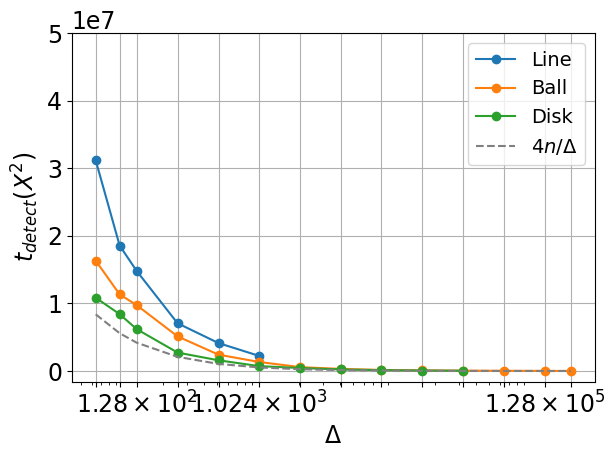

In [ ]:
file_paths = glob.glob('./results/detection_time_cauchy/*')
df_list = [pd.read_csv(file) for file in file_paths if os.path.isfile(file) ]
df = pd.concat(df_list, ignore_index=True)
print(f"Surface values: {df['D'].unique()}")

plot_detection_vs_surface(df,fixed_mu=2,fixed_n_volume=134217728,fixed_probability=1,fixed_n_targets=1, fixed_n_walkers=1)


# Figure 2 (b)

In [57]:
def plot_detection_vs_mu_for_all_surface(df, fixed_n,
                                   fixed_n_volume=None,
                                   fixed_n_targets=None,
                                   fixed_probability=None,
                                   target_shapes=None,
                                   save_path=None,
                                   parameters = None):
    # Base filtering
    base_filter = (df['n_walkers'] == fixed_n)
    if fixed_n_volume is not None:
        base_filter &= (df['n_volume'] == fixed_n_volume)
    if fixed_n_targets is not None:
        base_filter &= (df['n_targets'] == fixed_n_targets)
    if fixed_probability is not None:
        base_filter &= (df['probability'] == fixed_probability)  # Considera solo D >= 2  
    if parameters is not None:
        base_filter &= df['surface'].isin(parameters)
    else:
        base_filter &= (df['surface'] > 100)
    subset = df[base_filter].copy()

    # Filter shapes if provided
    if target_shapes is not None:
        subset = subset[subset['TargetShape'].isin(target_shapes)]

    # Grouping
    group_cols = ['mu', 'surface', 'TargetShape', 'n_walkers']
    if fixed_n_volume is not None:
        group_cols.append('n_volume')
    if fixed_n_targets is not None:
        group_cols.append('n_targets')
    if fixed_probability is not None:
        group_cols.append('probability')

    stats = subset.groupby(group_cols)['detection_time'].agg(['mean']).reset_index()
    stats = stats.rename(columns={'mean': 'detection_time_mean'})

    plt.figure(figsize=(8, 6))    

    # Define line styles for shapes (max 2 shapes)
    line_styles = ['-', '--']

    # Get shape list (for legend later)
    unique_shapes = sorted(stats['TargetShape'].unique())
    shape_style_map = {shape: line_styles[i % len(line_styles)] for i, shape in enumerate(unique_shapes)}

    # Create color palette for each diameter
    unique_surface = sorted(stats['surface'].unique())
    colors = plt.cm.tab10.colors  # Enough distinct colors

    # Plotting
    for color_idx, surface_val in enumerate(unique_surface):
        dia_data = stats[stats['surface'] == surface_val]
        for shape in unique_shapes:
            shape_data = dia_data[dia_data['TargetShape'] == shape].sort_values('mu')
            if shape_data.empty:
                continue
            plt.plot(shape_data['mu'],
                     shape_data['detection_time_mean'],
                     color=colors[color_idx % len(colors)],
                     linestyle=shape_style_map[shape],
                     marker='o')
            

    # Legend for diameters (colors)
    # Legend for diameters (colors)
    surface_handles = [
        plt.Line2D([0], [0], color=colors[i % len(colors)], lw=2)
        for i in range(len(unique_surface))
    ]
    surface_labels = [f"{d}" for d in unique_surface]

    # Legend for shapes (line styles)
    if len(unique_shapes) > 1:
        shape_handles = [
            plt.Line2D([0], [0], color='black', linestyle=shape_style_map[s], lw=2)
            for s in unique_shapes
        ]
        def get_title(shape):
            if shape == "Ball":
                return "Ball"
            elif shape == "Ball_boundary":
                return "Boundary"
            else:
                return shape
        shape_labels = [get_title(s) for s in unique_shapes]
    else:
        shape_handles = []
        shape_labels = []

    # Merge legends
    all_handles = surface_handles + shape_handles
    all_labels = surface_labels + shape_labels

    legend = plt.legend(
        all_handles,
        all_labels,
        framealpha=0.5,
        loc="upper right",
        ncol=4,
        columnspacing=0.8,
    )


    plt.gca().add_artist(legend)  # Keep both legends

    # Axis and title
    plt.xticks(sorted(stats['mu'].unique()))
    plt.xlabel(r'$\mu$')
    plt.yscale('log')
    plt.ylabel(r'$t_{detect}(X^{\mu})$')

    titolo = f'Detection Time vs μ'
    if fixed_n_volume is not None:
        side = round(fixed_n_volume ** (1/3))
        titolo += f', side={side}'
    if fixed_n_targets is not None:
        titolo += f', n_targets={fixed_n_targets}'
    if fixed_probability is not None:
        titolo += f', p={fixed_probability}'
    titolo += ')'
    #plt.title(titolo)

    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()
    plt.close()


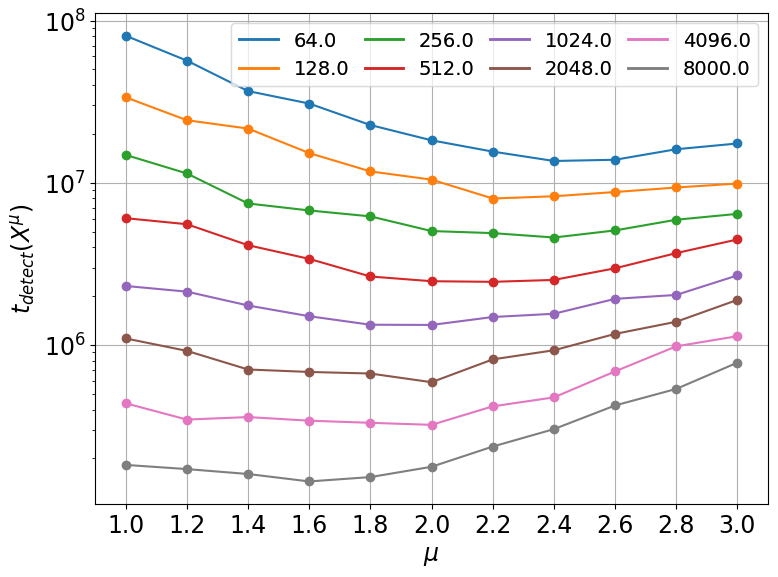

In [ ]:
file_paths = glob.glob('./results/detection_time_mu/*')
df_list = [pd.read_csv(file) for file in file_paths if os.path.isfile(file) ]
df = pd.concat(df_list, ignore_index=True)

plot_detection_vs_mu_for_all_surface(df, fixed_n=1, fixed_n_volume=134217728, fixed_probability=1, fixed_n_targets=1, target_shapes=['Ball'], parameters = [8,16,32,64,128, 256, 512, 1024, 2048, 4096, 8000])

# Figure 2 (b+c)

In [43]:
def plot_detection_ratio_vs_mu_for_all_surface(df, fixed_n,
                                         fixed_n_volume=None,
                                         fixed_n_targets=None,
                                         fixed_probability=None,
                                         target_shapes=None,
                                         save_path=None,
                                         parameters = None):
    import matplotlib.pyplot as plt
    import numpy as np

    base_filter = (df['n_walkers'] == fixed_n)
    if fixed_n_volume is not None:
        base_filter &= (df['n_volume'] == fixed_n_volume)
    if fixed_n_targets is not None:
        base_filter &= (df['n_targets'] == fixed_n_targets)
    if fixed_probability is not None:
        base_filter &= (df['probability'] == fixed_probability)
    
    if parameters is not None:
        base_filter &= df['surface'].isin(parameters)
    else:
        base_filter &= (df['surface'] > 100)  # Considera solo D >= 2    
    subset = df[base_filter].copy()
    
    if target_shapes is not None:
        subset = subset[subset['TargetShape'].isin(target_shapes)]

    group_cols = ['mu', 'surface', 'TargetShape', 'n_walkers']
    if fixed_n_volume is not None:
        group_cols.append('n_volume')
    if fixed_n_targets is not None:
        group_cols.append('n_targets')
    if fixed_probability is not None:
        group_cols.append('probability')

    stats = subset.groupby(group_cols)['detection_time'].mean().reset_index()
    stats = stats.rename(columns={'detection_time': 'detection_time_mean'})

    plt.figure(figsize=(8, 6))
    line_styles = ['-', '--']
    unique_shapes = sorted(stats['TargetShape'].unique())
    shape_style_map = {shape: line_styles[i % len(line_styles)] for i, shape in enumerate(unique_shapes)}
    unique_diameters = sorted(stats['surface'].unique())
    colors = plt.cm.tab10.colors

    for color_idx, D_val in enumerate(unique_diameters):
        dia_data = stats[stats['surface'] == D_val]
        base_mu2 = dia_data[dia_data['mu'] == 2].set_index('TargetShape')['detection_time_mean']
        if base_mu2.empty:
            continue
        for shape in unique_shapes:
            shape_data = dia_data[dia_data['TargetShape'] == shape].sort_values('mu')
            if shape_data.empty or shape not in base_mu2:
                continue
            ratio = shape_data['detection_time_mean'] / base_mu2[shape]
            plt.plot(shape_data['mu'],
                     ratio,
                     color=colors[color_idx % len(colors)],
                     linestyle=shape_style_map[shape],
                     marker='o')

    plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)

    diameter_handles = [plt.Line2D([0], [0], color=colors[i % len(colors)], lw=2)
                        for i in range(len(unique_diameters))]
    diameter_labels = [rf"{d}" for d in unique_diameters]
    legend1 = plt.legend(diameter_handles, diameter_labels, framealpha=0.5, loc='upper center', ncol=2)
    if len(unique_shapes) > 1:
        shape_handles = [plt.Line2D([0], [0], color='black', linestyle=shape_style_map[s], lw=2)
                        for s in unique_shapes]
        legend2 = plt.legend(shape_handles, unique_shapes, title="Shape", loc='lower right')
    plt.gca().add_artist(legend1)

    plt.xticks(sorted(stats['mu'].unique()))
    plt.xlabel(r'$\mu$')
    plt.ylabel(r'$t_{\mathrm{detect}}(X^\mu)/t_{\mathrm{detect}}(X^2)$')
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()
    plt.close()


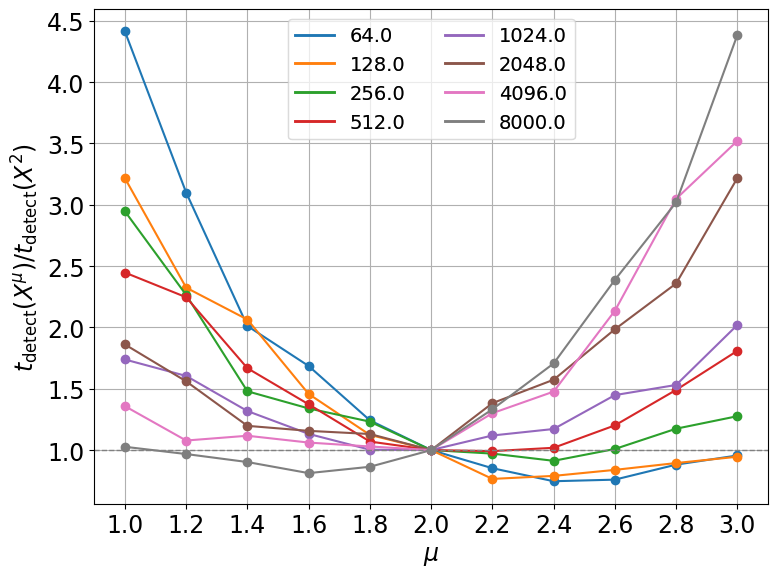

In [ ]:
file_paths = glob.glob('./results/detection_time_mu/*')
df_list = [pd.read_csv(file) for file in file_paths if os.path.isfile(file) ]
df = pd.concat(df_list, ignore_index=True)

plot_detection_ratio_vs_mu_for_all_surface(df, fixed_n_targets=1, fixed_n=1, fixed_n_volume=134217728, fixed_probability=1, target_shapes=['Ball'], parameters = [8,16,32,64,128, 256, 512, 1024, 2048, 4096, 8000])

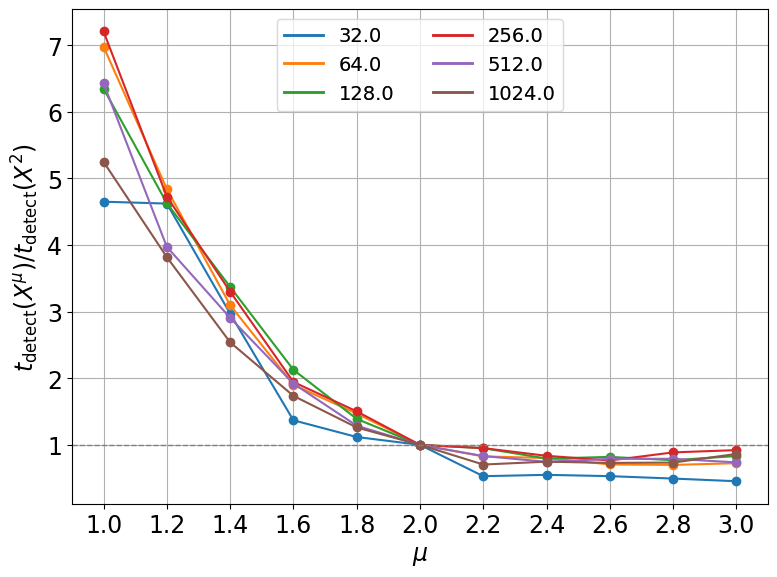

In [ ]:
file_paths = glob.glob('./results/detection_time_mu/*')
df_list = [pd.read_csv(file) for file in file_paths if os.path.isfile(file) ]
df = pd.concat(df_list, ignore_index=True)

plot_detection_ratio_vs_mu_for_all_surface(df, fixed_n_targets=1, fixed_n=1, fixed_n_volume=134217728, fixed_probability=1, target_shapes=['Line'], parameters = [8,16,32,64,128, 256, 512, 1024])

# Figure 3 (a + b)

In [22]:
def plot_detection_time_vs_delta_by_mu_facets(
    df,
    output_dir=None,
    filename="detection_time_vs_delta_by_surface_grid.png",
    mu_filter=[2.0, 2.5, 3.0],
    surface_filter=[50, 100, 200, 300, 400, 500]  # now includes 200
):
    """
    Creates a 2x2 grid of small multiples: each subplot corresponds to a surface D.
    Each subplot shows detection_time vs delta for different μ.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Must contain 'delta', 'detection_time', 'mu', 'D'
    output_dir : str
        Directory where the plot will be saved
    filename : str
        Output filename
    mu_filter : list of floats
        μ values to include
    surface_filter : list of floats or ints
        D values to include
    """
    required_cols = {"delta", "detection_time", "mu", "D"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Filter dataframe
    df = df[df['mu'].isin(mu_filter)]
    if surface_filter is not None:
        df = df[df['D'].isin(surface_filter)]
    if df.empty:
        print("No data to plot after filtering!")
        return

    # Average detection_time per (mu, delta, D)
    grouped = (
        df.groupby(["mu", "delta", "D"])["detection_time"]
        .mean()
        .reset_index()
        .sort_values("delta")
    )

    surfaces = sorted(grouped['D'].unique())
    n_surfaces = len(surfaces)
    # Determine grid layout: 2x2
    n_rows = 2
    n_cols = 2

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(4*n_cols, 3*n_rows),
        sharey=True
    )

    # Flatten axes array for easy iteration
    axes = axes.flatten()
    print(axes)
    # Colors for different μ
    cmap = plt.cm.viridis
    mu_vals = sorted(grouped['mu'].unique())
    colors = {mu: cmap(i / (len(mu_vals)-1)) for i, mu in enumerate(mu_vals)}

    for ax, D_val in zip(axes, surfaces):
        sub_D = grouped[grouped['D'] == D_val]
        for mu_val, sub_mu in sub_D.groupby("mu"):
            ax.plot(
                sub_mu["delta"],
                sub_mu["detection_time"],
                marker="o",
                #color=colors[mu_val],
                label=f"$\mu={mu_val}$"
            )
        ax.set_title(f"$\\Delta={D_val}$")
        ax.set_xlabel(r"$\delta$")
        ax.grid(True)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

        # set max y limit
        #ax.set_ylim(0, grouped['detection_time'].max()*1.3)

    # Hide any unused subplots (if surface_filter < 4)
    for ax in axes[n_surfaces:]:
        ax.axis('off')

    axes[0].set_ylabel(r"$t^{x^\mu}_{\mathrm{detect}}(S)$")
    axes[2].set_ylabel(r"$t^{x^\mu}_{\mathrm{detect}}(S)$")

    # Add a single legend outside the plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(mu_vals), bbox_to_anchor=(0.5, 1.05))

    plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for legend

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, filename)
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {output_path}")
    else:
        plt.show()
    plt.close()
    

<>:74: SyntaxWarning: invalid escape sequence '\m'
<>:74: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1672816/1868184235.py:74: SyntaxWarning: invalid escape sequence '\m'
  label=f"$\mu={mu_val}$"


[<Axes: > <Axes: > <Axes: > <Axes: >]


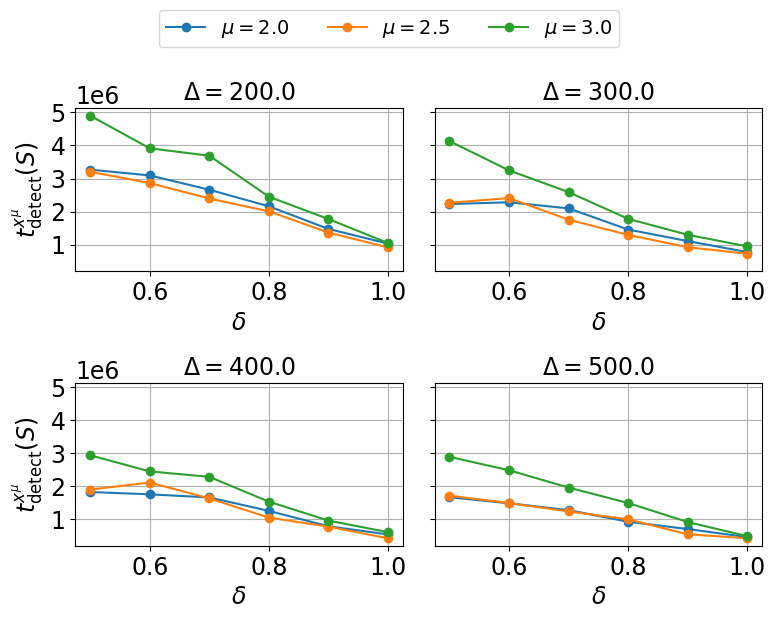

In [23]:
file_paths = glob.glob('./results/detection_time_small_delta/*')
df_list = [pd.read_csv(file) for file in file_paths if os.path.isfile(file) ]
df = pd.concat(df_list, ignore_index=True)
    
plot_detection_time_vs_delta_by_mu_facets(df, filename="detection_time_vs_delta_by_mu.png", mu_filter = [2.0, 2.5, 3.0], surface_filter=[200, 300, 400, 500])

[<Axes: > <Axes: > <Axes: > <Axes: >]


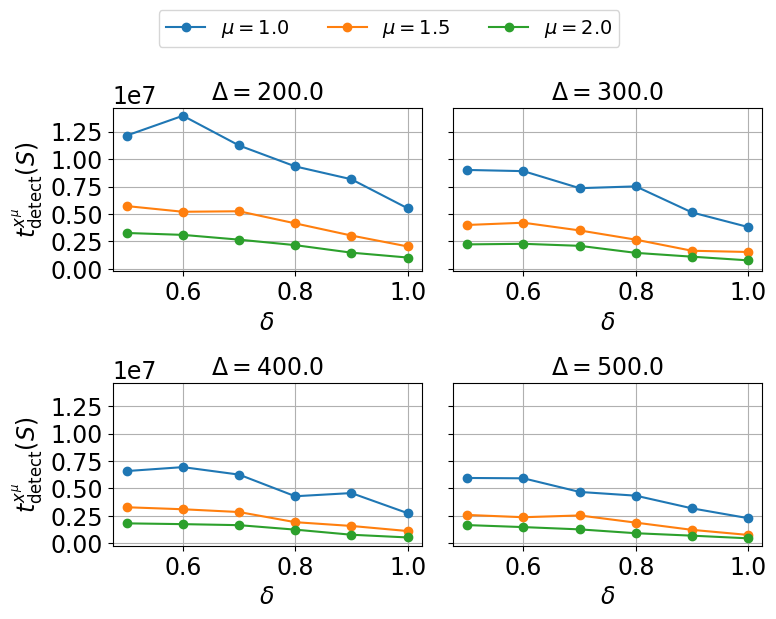

In [25]:

plot_detection_time_vs_delta_by_mu_facets(df, filename="detection_time_vs_delta_by_mu.png", mu_filter = [1.0, 1.5, 2.0], surface_filter=[200, 300, 400, 500])

[<Axes: > <Axes: > <Axes: > <Axes: >]


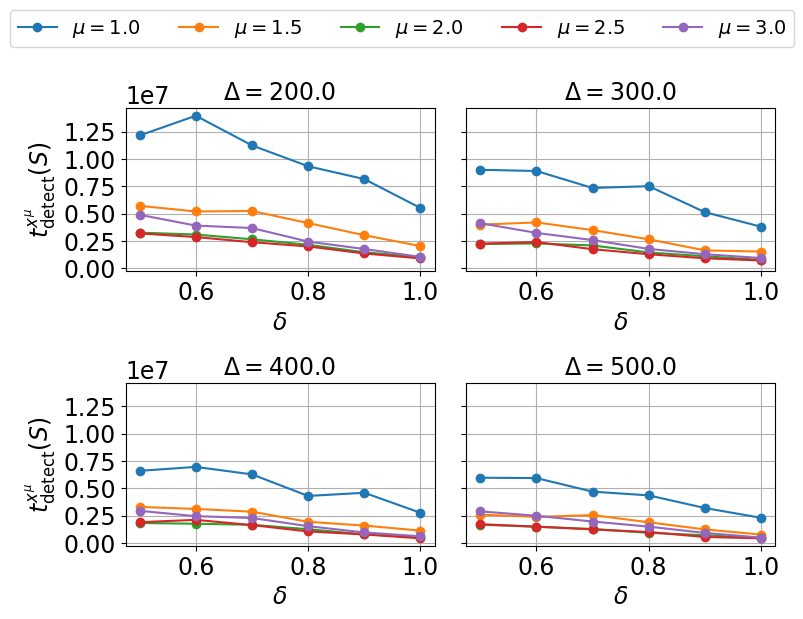

In [26]:
plot_detection_time_vs_delta_by_mu_facets(df, filename="detection_time_vs_delta_by_mu.png", mu_filter = [1.0, 1.5, 2.0, 2.5, 3.0], surface_filter=[200, 300, 400, 500])

# Other experiments

# Surface vs volume

In [ ]:
def plot_detection_time_ratio(
    df,
    n_walkers,
    n_targets,
    fixed_target_dist,
    probability,
    mu_list,
    reference_shape = "Disk",
    output_path=None
):
    # -----------------------------------------------
    # Filter fixed parameters
    # -----------------------------------------------
    df = df[
        (df['n_walkers'] == n_walkers) &
        (df['n_targets'] == n_targets) &
        (df['fixed_target_dist'] == fixed_target_dist) &
        (df['probability'] == probability)
        ]


    if df.empty:
        print("No matching data found for the given fixed parameters.")
        return

    if "DiskDiameter" not in df.columns:
        raise ValueError("Dataset must contain 'DiskDiameter'.")

    

    # -----------------------------------------------
    # First pass: compute global y-limits and store data
    # -----------------------------------------------
    y_values = []
    precomputed = {}

    for mu_val in mu_list:
        subset = df[df['mu'] == mu_val]
        if subset.empty:
            continue

        grouped = subset.groupby(
            ['TargetShape', 'DiskDiameter', 'D']
        )['detection_time'].mean().reset_index()

        ball_df = grouped[grouped['TargetShape'] == 'Ball_no_boundary'] \
                    .sort_values('DiskDiameter').copy()
        disk_df = grouped[grouped['TargetShape'] == reference_shape] \
                    .sort_values('DiskDiameter').copy()

        # Align diameters
        ball_df['DiskDiameter'] += 2
        disk_df['DiskDiameter'] += 2

        common_diam = np.intersect1d(
            ball_df['DiskDiameter'], disk_df['DiskDiameter']
        )
        if len(common_diam) == 0:
            continue

        ball_df = ball_df[ball_df['DiskDiameter'].isin(common_diam)]
        disk_df = disk_df[disk_df['DiskDiameter'].isin(common_diam)]

        time_ratio = (
            ball_df['detection_time'].values /
            disk_df['detection_time'].values
        )
        y_values.extend(time_ratio)

        precomputed[mu_val] = (common_diam, ball_df, disk_df, time_ratio)

    if len(y_values) == 0:
        print("No valid Ball/Disk matched data for requested μ values.")
        return

    # y-limits with padding
    y_min, y_max = min(y_values), max(y_values)
    padding = 0.05 * (y_max - y_min)
    y_min -= padding
    y_max += padding

    # -----------------------------------------------
    # Single plot
    # -----------------------------------------------
    plt.figure(figsize=(8, 6))

    mu_handles = []
    theo_handle = None

    for mu_val in mu_list:
        if mu_val not in precomputed:
            continue

        common_diam, ball_df, disk_df, time_ratio = precomputed[mu_val]

        h_mu, = plt.plot(common_diam, time_ratio, 'o-', label=f"μ = {mu_val}")
        mu_handles.append(h_mu)



        # Add theoretical ratio only for mu = 2
        if mu_val == 2:
            if reference_shape == "Disk":
                theo_ratio = 1
                label = r"$D^{2}_{disk}/D^{2}_{ball}$"
            elif reference_shape == "Line":
                theo_ratio = (17/40)*(disk_df['D'].values)**(1/3)
                label = r"$\frac{2}{5}\sqrt[3]{D_{Line}}$"
            else:
                raise ValueError(f"Unknown reference shape: {reference_shape}")
            theo_handle, = plt.plot(
                common_diam, theo_ratio, '--', color='gray',
                label=label
            )

    handles = mu_handles + ([theo_handle] if theo_handle is not None else [])
    labels = [h.get_label() for h in handles]

    plt.axhline(1.0, color='gray', linestyle=':', linewidth=1)

    plt.xlabel(r"Line diameter - $D_{Line}$")
    if reference_shape == "Disk":
        ylabel = r"$t_{detect}^{Ball}(X^\mu)/t_{detect}^{Disk}(X^\mu)$"
    elif reference_shape == "Line":
        ylabel = r"$t_{detect}^{Ball}(X^\mu)/t_{detect}^{Line}(X^\mu)$"
    else:
        raise ValueError(f"Unknown reference shape: {reference_shape}")
    plt.ylabel(ylabel)
    plt.ylim(y_min, y_max)
    plt.grid(True)
    plt.legend(handles, labels)

    plt.tight_layout()

    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, bbox_inches="tight")
    else:
        plt.show()
    plt.close()



Surface values: [ 13.43 200.    14.46 250.    15.36 300.    16.16 350.    16.9  400.
  17.57 450.    18.2  500.     4.38   5.     5.24  10.     6.42  20.
   8.55  50.    10.7  100.    12.22 150.  ]


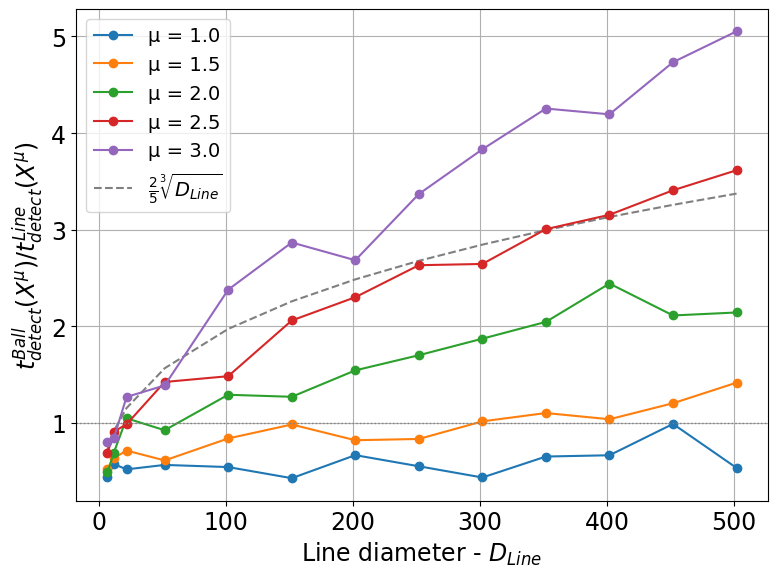

In [ ]:
file_paths = glob.glob('./results/surface/fixed_volume/*')
df_list = [pd.read_csv(file) for file in file_paths if os.path.isfile(file) ]
df = pd.concat(df_list, ignore_index=True)
print(f"Surface values: {df['D'].unique()}")


plot_detection_time_ratio(df,n_walkers=1,n_targets=1,fixed_target_dist=0,probability=1.0, reference_shape = 'Line',mu_list=[1.0,1.5,2.0,2.5,3.0])
